# Pseudospectrum test case: L-shape $[0,2]^2\setminus[1,2]^2$, $R_m = 20$, zero wind

A self-contained check of `pseudospectra.py` on a geometry that is **not** the one used
elsewhere in the study, so that nothing is inherited from a previously tuned setup.

| | |
|---|---|
| domain | $\Omega = [0,2]^2 \setminus [1,2]^2$, re-entrant corner at $(1,1)$, interior angle $3\pi/2$ |
| wind | $\mathbf{u} = \mathbf{0}$ |
| $R_m$ | $20$, i.e. $\varepsilon = 1/R_m = 0.05$ |
| discretisation | B-formulation, $\mathrm{N1curl}_1 \times \mathrm{CG}_1$ |
| target | eigenvalues near $\lambda = 10$ |

The mesh constructor is defined **locally in this notebook** rather than imported from
`functions.py`.

With $\mathbf{u} = \mathbf{0}$ the advection term drops out and the operator is
self-adjoint, so $R_m$ only rescales the spectrum by $1/R_m$. That makes this a strong
test rather than an interesting physics case: a normal operator has
$\sigma_{\min}(z) = \operatorname{dist}(z, \sigma(\mathcal{L}))$ **exactly**, which the
last cell checks to machine precision.

In [3]:
import numpy as np
import matplotlib.pyplot as plt

from firedrake import *
from firedrake.cython import dmcommon
from firedrake.mesh import plex_from_cell_list
from firedrake.pyplot import triplot

# after the star-import, since firedrake exports a `logging` of its own
import logging as pylogging

from functions import FEEC_B_N1_2d1k, B_formulation_2d1k, bcs_B_2d1k
from pseudospectra import pseudospectrum, plot_pseudospectrum

## The mesh

Local to this notebook. Start from a uniform $2n \times 2n$ grid on $[0,2]^2$, drop the
cells of the top-right quadrant $[1,2]^2$, then split each remaining square into four
triangles about its centre (`crossed`).

In [4]:
def make_Lshape_mesh(n=16, diagonal="crossed", comm=COMM_WORLD, name="L_shape_02"):
    r"""Structured mesh of the L-shaped domain [0, 2]^2 \ [1, 2]^2.

    The re-entrant corner is at (1, 1), with interior angle 3*pi/2.

    Parameters
    ----------
    n : int
        Cells per unit length, so the enclosing square carries 2n per side.
    diagonal : {"crossed", "left", "right"}
        How each grid square is split into triangles, as in RectangleMesh.

    Returns
    -------
    Mesh
        with boundary markers

            1 : x = 0                      4 : y = 2  (0 <= x <= 1)
            2 : x = 2  (0 <= y <= 1)       5 : x = 1  (1 <= y <= 2)  re-entrant
            3 : y = 0                      6 : y = 1  (1 <= x <= 2)  re-entrant
    """
    if n < 1:
        raise ValueError("n must be a positive integer")
    if diagonal not in ("crossed", "left", "right"):
        raise ValueError(f"Unknown diagonal '{diagonal}'")

    h = 1.0 / n
    N = 2 * n

    # Vertex (i, j) sits at (i*h, j*h) and has index i*(N+1) + j.
    grid = np.arange(N + 1) * h
    gx, gy = np.meshgrid(grid, grid, indexing="ij")
    coords = np.column_stack([gx.ravel(), gy.ravel()])

    # Drop the top-right quadrant: x >= 1 <=> i >= n, and y >= 1 <=> j >= n.
    i, j = np.meshgrid(np.arange(N), np.arange(N), indexing="ij")
    keep = ~((i >= n) & (j >= n))
    i, j = i[keep], j[keep]

    # Corners of each retained square, counter-clockwise from bottom-left.
    v00 = i * (N + 1) + j
    v10 = v00 + (N + 1)
    v11 = v10 + 1
    v01 = v00 + 1

    if diagonal == "right":
        cells = np.vstack([np.column_stack([v00, v10, v11]),
                           np.column_stack([v00, v11, v01])])
    elif diagonal == "left":
        cells = np.vstack([np.column_stack([v00, v10, v01]),
                           np.column_stack([v10, v11, v01])])
    else:
        centre = len(coords) + np.arange(len(i))
        coords = np.vstack([coords,
                            np.column_stack([(i + 0.5) * h, (j + 0.5) * h])])
        cells = np.vstack([np.column_stack([v00, v10, centre]),
                           np.column_stack([v10, v11, centre]),
                           np.column_stack([v11, v01, centre]),
                           np.column_stack([v01, v00, centre])])

    # Drop unreferenced vertices and renumber.
    used, inverse = np.unique(cells, return_inverse=True)
    cells = inverse.reshape(-1, 3)
    coords = coords[used]

    plex = plex_from_cell_list(2, cells, coords, comm)
    _mark_lshape_boundaries(plex, tol=0.25 * h)
    return Mesh(plex, name=name, comm=comm)


def _mark_lshape_boundaries(plex, tol):
    """Tag the six boundary segments; see make_Lshape_mesh for the markers."""
    plex.createLabel(dmcommon.FACE_SETS_LABEL)
    plex.markBoundaryFaces("boundary_faces")

    if plex.getStratumSize("boundary_faces", 1) > 0:
        coords = plex.getCoordinates()
        coord_sec = plex.getCoordinateSection()

        for face in plex.getStratumIS("boundary_faces", 1).getIndices():
            x, y = (plex.vecGetClosure(coord_sec, coords, face)
                    .reshape(-1, 2).mean(axis=0))

            if abs(x) < tol:
                marker = 1
            elif abs(x - 2.0) < tol:
                marker = 2
            elif abs(y) < tol:
                marker = 3
            elif abs(y - 2.0) < tol:
                marker = 4
            elif abs(x - 1.0) < tol:
                marker = 5
            elif abs(y - 1.0) < tol:
                marker = 6
            else:
                raise RuntimeError(
                    f"Could not classify boundary face with midpoint ({x}, {y})")

            plex.setLabelValue(dmcommon.FACE_SETS_LABEL, face, marker)

    plex.removeLabel("boundary_faces")

cells      : 12288
area       : 3.0000000000   (expected 3)
boundaries : [2.0, 1.0, 2.0, 1.0, 1.0, 1.0]   (expected [2.0, 1.0, 2.0, 1.0, 1.0, 1.0])


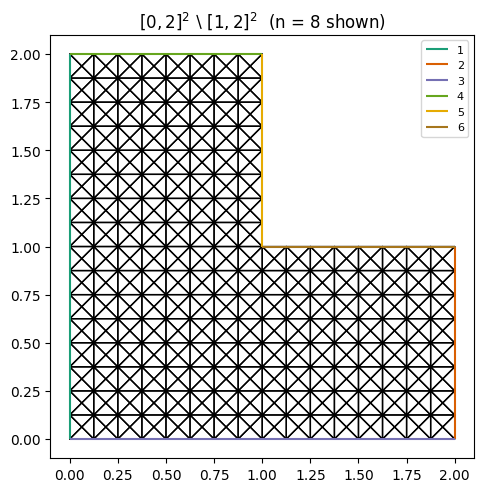

In [5]:
mesh = make_Lshape_mesh(n=32, diagonal="crossed")

# Geometry checks: |Omega| = 4 - 1 = 3, and the six boundary segments have
# lengths 2, 1, 2, 1, 1, 1 (perimeter 8).
area = assemble(Constant(1.0) * dx(domain=mesh))
lengths = [float(assemble(Constant(1.0) * ds(k, domain=mesh))) for k in range(1, 7)]
print(f"cells      : {mesh.num_cells()}")
print(f"area       : {area:.10f}   (expected 3)")
print(f"boundaries : {[round(v, 10) for v in lengths]}"
      f"   (expected [2.0, 1.0, 2.0, 1.0, 1.0, 1.0])")
assert abs(area - 3.0) < 1e-12
assert np.allclose(lengths, [2.0, 1.0, 2.0, 1.0, 1.0, 1.0])

fig, ax = plt.subplots(figsize=(5.5, 5.5))
# triplot re-queries the face labels and reports every one of them empty; the
# ds() integrals above show they are in fact marked correctly, so quieten it.
_fd_log = pylogging.getLogger("firedrake")
_level = _fd_log.level
_fd_log.setLevel(pylogging.ERROR)
try:
    triplot(make_Lshape_mesh(n=8), axes=ax)   # coarse copy, to see the geometry
finally:
    _fd_log.setLevel(_level)
ax.set_aspect("equal")
ax.set_title(r"$[0,2]^2 \setminus [1,2]^2$  (n = 8 shown)")
ax.legend(loc="upper right", fontsize=8)
plt.show()

## Problem setup

$R_m = 20$, so $\varepsilon = 1/R_m$. Zero wind is `u=None`, which omits the
$\langle v \times u, \operatorname{curl} w\rangle$ term entirely.

In [18]:
Rm = 1.0

def wind_func_heaviside_y(mesh):
    x,y = SpatialCoordinate(mesh)
    y0 = Constant(np.pi / 2.0)
    return as_vector([sign(y - y0), Constant(0.0)])

    
W = FEEC_B_N1_2d1k(mesh=mesh, degree=1)
a, m = B_formulation_2d1k(W, u=wind_func_heaviside_y(mesh), eps=Constant(1.0 / Rm))
bcs = bcs_B_2d1k(W)

print(f"mixed space dimension : {W.dim()}")
print(f"  N1curl_1            : {W.sub(0).dim()}")
print(f"  CG_1                : {W.sub(1).dim()}")

mixed space dimension : 24833
  N1curl_1            : 18560
  CG_1                : 6273


## Pseudospectrum near $\lambda = 10$

The window is kept inside the range of eigenvalues the reduced basis actually captures;
the cell below prints that range so the choice can be checked rather than assumed.

mixed space dimension : 24833
  N1curl_1            : 18560
  CG_1                : 6273
pencil size 24321, solving for 10 eigenpairs near 1.0 ...
  11 converged, 11 finite eigenvalues retained
  reduced dimension 11, cond(B_r) = 1.00e+00, eigenvalue reproduction error = 1.41e-12
  evaluating sigma_min on a 220x220 grid ...


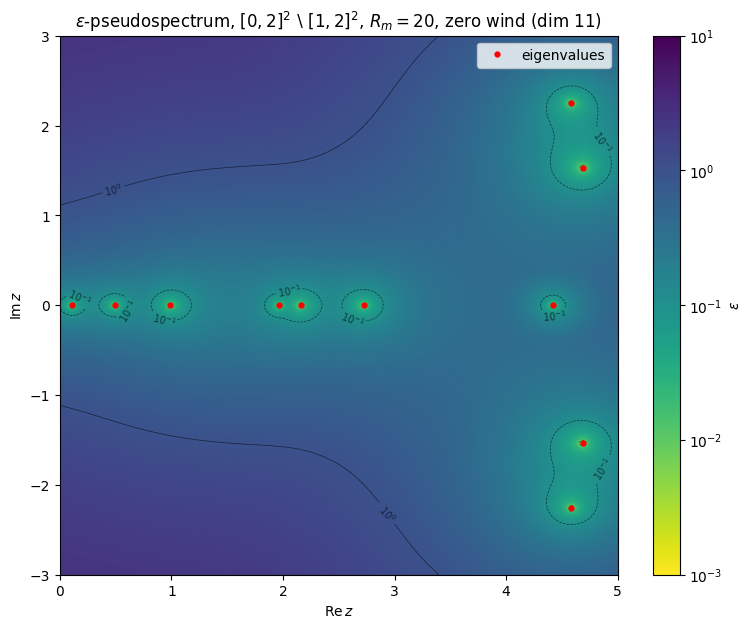

retained eigenvalues : 0.1065 .. 4.6851  (11 of them)
window               : 0 .. 5.0
nearest 10 to target : [0.9919 0.4908 0.1065 1.9637 2.1583 2.7241 4.4199 4.5842 4.5842 4.6851]


In [45]:
Rm = 20

def wind_func_heaviside_y(mesh):
    x,y = SpatialCoordinate(mesh)
    y0 = Constant(np.pi / 2.0)
    return as_vector([sign(y - y0), Constant(0.0)])

    
W = FEEC_B_N1_2d1k(mesh=mesh, degree=1)
a, m = B_formulation_2d1k(W, u=wind_func_heaviside_y(mesh), eps=Constant(1.0 / Rm))
bcs = bcs_B_2d1k(W)

print(f"mixed space dimension : {W.dim()}")
print(f"  N1curl_1            : {W.sub(0).dim()}")
print(f"  CG_1                : {W.sub(1).dim()}")

target = 1.0
real_range, imag_range = (0, 5.0), (-3, 3)

result, ax = plot_pseudospectrum(
    a, m, target, real_range, imag_range,
    bcs=bcs, nev=10, res=220, norm="mass",
)
ax.set_title(rf"$\varepsilon$-pseudospectrum, $[0,2]^2\setminus[1,2]^2$, "
             rf"$R_m={Rm:g}$, zero wind (dim {result['dim']})")
plt.show()

ev = np.sort(result["eigenvalues"].real)
print(f"retained eigenvalues : {ev.min():.4f} .. {ev.max():.4f}  ({ev.size} of them)")
print(f"window               : {real_range[0]} .. {real_range[1]}")
if ev.min() > real_range[0] or ev.max() < real_range[1]:
    print("WARNING: the window reaches past the captured spectrum; increase nev")
print(f"nearest 10 to target : {np.round(ev[np.argsort(abs(ev - target))][:10], 4)}")

mixed space dimension : 24833
  N1curl_1            : 18560
  CG_1                : 6273
pencil size 24321, solving for 50 eigenpairs near 1.0 ...
  55 converged, 55 finite eigenvalues retained
  reduced dimension 55, cond(B_r) = 1.00e+00, eigenvalue reproduction error = 4.38e-12
  evaluating sigma_min on a 220x220 grid ...


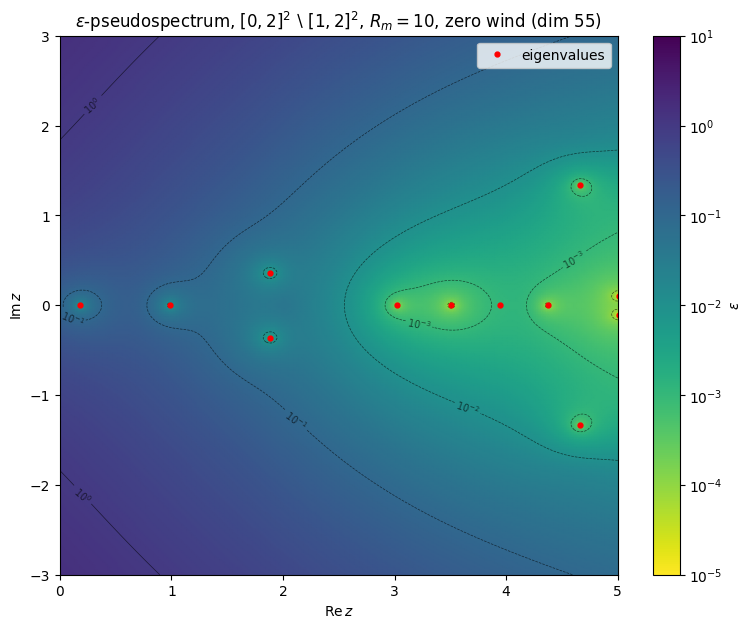

retained eigenvalues : 0.1847 .. 21.0873  (55 of them)
window               : 0 .. 5.0
nearest 10 to target : [0.9857 0.1847 1.8833 1.8833 3.0262 3.5092 3.9435 4.3728 4.6626 4.6626]


In [44]:
Rm = 10.0

def wind_func_heaviside_y(mesh):
    x,y = SpatialCoordinate(mesh)
    y0 = Constant(np.pi / 2.0)
    return as_vector([sign(y - y0), Constant(0.0)])

    
W = FEEC_B_N1_2d1k(mesh=mesh, degree=1)
a, m = B_formulation_2d1k(W, u=wind_func_heaviside_y(mesh), eps=Constant(1.0 / Rm))
bcs = bcs_B_2d1k(W)

print(f"mixed space dimension : {W.dim()}")
print(f"  N1curl_1            : {W.sub(0).dim()}")
print(f"  CG_1                : {W.sub(1).dim()}")

target = 1.0
real_range, imag_range = (0, 5.0), (-3, 3)

result, ax = plot_pseudospectrum(
    a, m, target, real_range, imag_range,
    bcs=bcs, nev=50, res=220, norm="mass",
)
ax.set_title(rf"$\varepsilon$-pseudospectrum, $[0,2]^2\setminus[1,2]^2$, "
             rf"$R_m={Rm:g}$, zero wind (dim {result['dim']})")
plt.show()

ev = np.sort(result["eigenvalues"].real)
print(f"retained eigenvalues : {ev.min():.4f} .. {ev.max():.4f}  ({ev.size} of them)")
print(f"window               : {real_range[0]} .. {real_range[1]}")
if ev.min() > real_range[0] or ev.max() < real_range[1]:
    print("WARNING: the window reaches past the captured spectrum; increase nev")
print(f"nearest 10 to target : {np.round(ev[np.argsort(abs(ev - target))][:10], 4)}")

mixed space dimension : 24833
  N1curl_1            : 18560
  CG_1                : 6273
pencil size 24321, solving for 100 eigenpairs near 1.0 ...
  117 converged, 117 finite eigenvalues retained
  reduced dimension 117, cond(B_r) = 1.00e+00, eigenvalue reproduction error = 7.68e-13
  evaluating sigma_min on a 220x220 grid ...


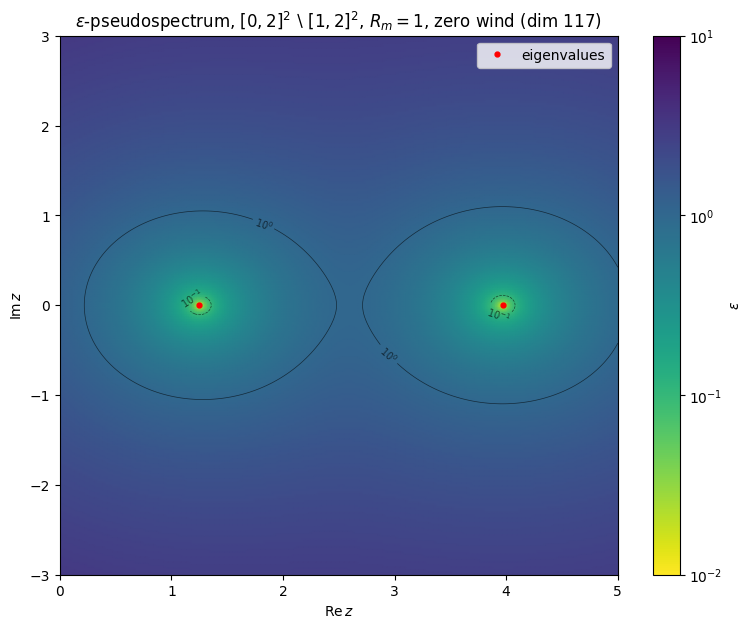

retained eigenvalues : 1.2517 .. 434.3452  (117 of them)
window               : 0 .. 5.0
nearest 10 to target : [ 1.2517  3.9696  9.8698 10.0925 11.9388 11.9388 19.9973 21.7004 23.665
 28.7186]


In [37]:
Rm = 1.0

def wind_func_heaviside_y(mesh):
    x,y = SpatialCoordinate(mesh)
    y0 = Constant(np.pi / 2.0)
    return as_vector([sign(y - y0), Constant(0.0)])

    
W = FEEC_B_N1_2d1k(mesh=mesh, degree=1)
a, m = B_formulation_2d1k(W, u=wind_func_heaviside_y(mesh), eps=Constant(1.0 / Rm))
bcs = bcs_B_2d1k(W)

print(f"mixed space dimension : {W.dim()}")
print(f"  N1curl_1            : {W.sub(0).dim()}")
print(f"  CG_1                : {W.sub(1).dim()}")

target = 1.0
real_range, imag_range = (0, 5.0), (-3, 3)

result, ax = plot_pseudospectrum(
    a, m, target, real_range, imag_range,
    bcs=bcs, nev=100, res=220, norm="mass",
)
ax.set_title(rf"$\varepsilon$-pseudospectrum, $[0,2]^2\setminus[1,2]^2$, "
             rf"$R_m={Rm:g}$, zero wind (dim {result['dim']})")
plt.show()

ev = np.sort(result["eigenvalues"].real)
print(f"retained eigenvalues : {ev.min():.4f} .. {ev.max():.4f}  ({ev.size} of them)")
print(f"window               : {real_range[0]} .. {real_range[1]}")
if ev.min() > real_range[0] or ev.max() < real_range[1]:
    print("WARNING: the window reaches past the captured spectrum; increase nev")
print(f"nearest 10 to target : {np.round(ev[np.argsort(abs(ev - target))][:10], 4)}")

## Tests

**1. Normality.** Zero wind makes the operator self-adjoint, hence normal, so the
$L^2$ pseudospectrum must be exactly the distance to the spectrum. Any error here is
error in the compression, not in the physics.

**2. Convergence in `nev`.** The reduced basis gives an inner approximation
($\sigma_{\min}$ from above), so the contours must stop moving as the subspace grows.

**3. Scaling in $R_m$.** With zero wind the operator is $\varepsilon\,\mathrm{curl\,curl}$
on the constrained space, so both the spectrum and $\sigma_{\min}$ must scale exactly
linearly in $\varepsilon = 1/R_m$.

In [6]:
# 1. normality: sigma_min(z) == dist(z, spectrum)
Z = result["X"] + 1j * result["Y"]
dist = np.min(np.abs(Z[..., None] - result["eigenvalues"][None, None, :]), axis=-1)
rel = np.abs(result["sigma"] - dist) / dist
print(f"[1] |sigma_min - dist(z, spectrum)| / dist :  max {rel.max():.3e}, "
      f"median {np.median(rel):.3e}")
print(f"    max |Im lambda| = {np.abs(result['eigenvalues'].imag).max():.2e}  "
      f"(spectrum is real, as it must be)")
assert rel.max() < 1e-8, "operator should be normal for zero wind"

# 2. convergence in nev
print("\n[2] convergence in nev")
for nev in (40, 80, 120):
    r = pseudospectrum(a, m, target, real_range, imag_range,
                       bcs=bcs, nev=nev, res=60, verbose=False)
    print(f"    nev={nev:3d}  dim={r['dim']:3d}  cond(B_r)={r['cond_Br']:.2e}  "
          f"eig err={r['eig_error']:.1e}  median sigma={np.median(r['sigma']):.6f}")

# 3. linearity in eps = 1/Rm
print("\n[3] scaling in Rm (zero wind => spectrum and sigma_min scale as 1/Rm)")
base = None
for Rm_test in (10.0, 20.0, 40.0):
    a_t, m_t = B_formulation_2d1k(W, u=None, eps=Constant(1.0 / Rm_test))
    r = pseudospectrum(a_t, m_t, target * 20.0 / Rm_test,
                       tuple(v * 20.0 / Rm_test for v in real_range),
                       tuple(v * 20.0 / Rm_test for v in imag_range),
                       bcs=bcs, nev=80, res=60, verbose=False)
    scaled = np.median(r["sigma"]) * Rm_test / 20.0
    base = scaled if base is None else base
    print(f"    Rm={Rm_test:5.1f}  median sigma x (Rm/20) = {scaled:.6f}  "
          f"(rel. dev. {abs(scaled - base) / base:.2e})")

[1] |sigma_min - dist(z, spectrum)| / dist :  max 9.631e-12, median 3.984e-15
    max |Im lambda| = 2.28e-14  (spectrum is real, as it must be)

[2] convergence in nev


    nev= 40  dim= 43  cond(B_r)=1.00e+00  eig err=9.8e-15  median sigma=1.050893


    nev= 80  dim= 83  cond(B_r)=1.00e+00  eig err=2.4e-14  median sigma=1.050893


    nev=120  dim=127  cond(B_r)=1.00e+00  eig err=2.6e-14  median sigma=1.050893

[3] scaling in Rm (zero wind => spectrum and sigma_min scale as 1/Rm)


    Rm= 10.0  median sigma x (Rm/20) = 1.050893  (rel. dev. 0.00e+00)


    Rm= 20.0  median sigma x (Rm/20) = 1.050893  (rel. dev. 8.87e-15)


    Rm= 40.0  median sigma x (Rm/20) = 1.050893  (rel. dev. 7.61e-15)
